In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from flonacomldft.utils.plots import plotting_fes_db
from flonacomldft.utils.io_utils import (
    get_project_path
)
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.collective_variables import get_CVs
from flonacomldft.internal_coordinates import Coordinates_mapping
from ase.io.trajectory import Trajectory

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an ind

[[10.21157328  2.46744986]
 [10.90880109  2.23341187]]


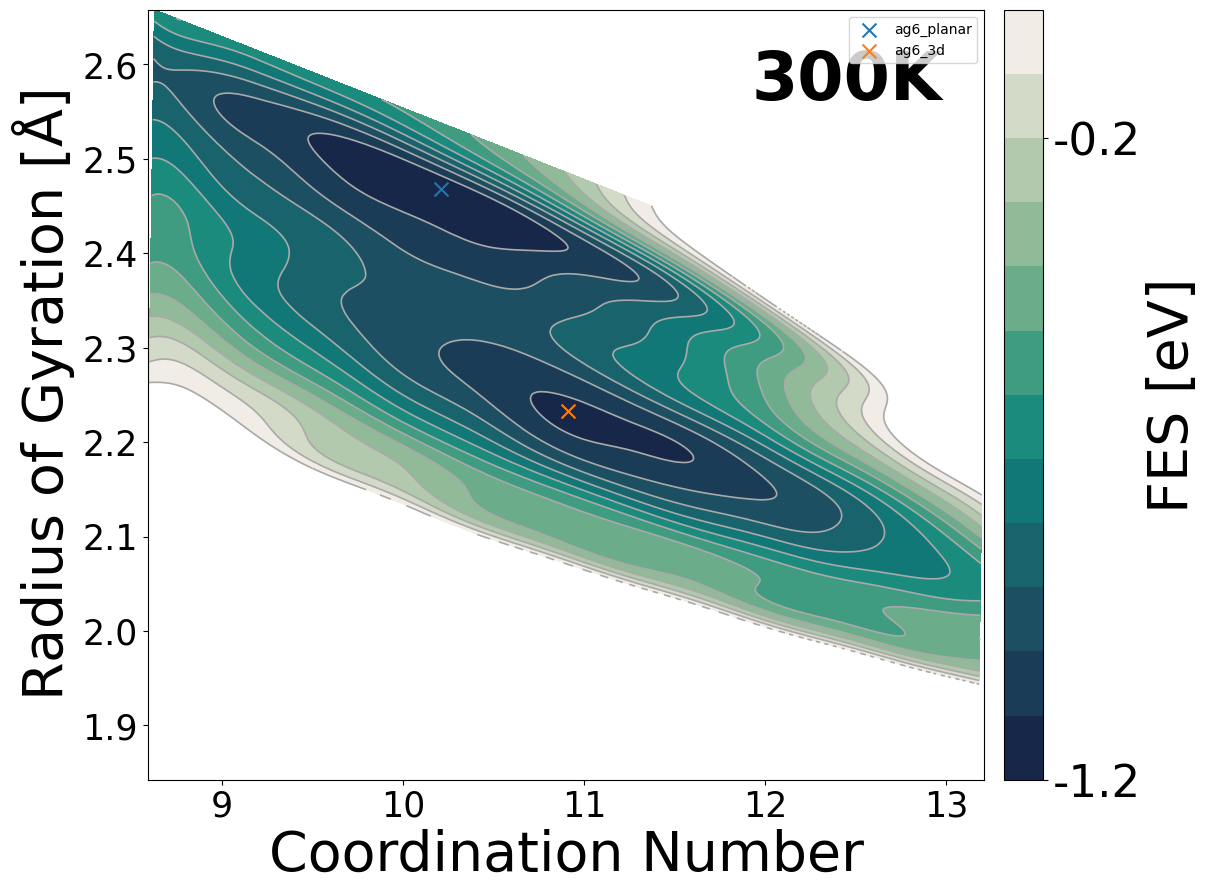

In [35]:
coord_mapping = Coordinates_mapping()
mode_names = ['ag6_planar', 'ag6_3d']
isomers_minima =  [coord_mapping.get_internal_from_molecule(get_molecule_isomer_minima(mode_name))[0] for mode_name in mode_names]

cv_minima = np.array(get_CVs(isomers_minima)).T
print(cv_minima)
fig, ax = plotting_fes_db()
for mode_name, cv in zip(mode_names, cv_minima):
    ax.scatter(*cv, marker='x', s=50, label=mode_name)
ax.legend()

In [4]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [5]:
mode_labels = [0, 1]
trajs_berendsen = [Trajectory(get_project_path() + '/database/md_trajectories/ag6_is{:d}_lcao.traj'.format(mode_label)) for mode_label in mode_labels]

temps = [[config.get_temperature() for config in traj] for traj in trajs_berendsen]

In [6]:
temps

[[383.75039621490856,
  379.8721382908131,
  370.6080310315828,
  356.95195592137026,
  339.81265858265647,
  320.0943001357939,
  298.7883927264764,
  276.8822887315634,
  255.18956571446026,
  234.2947615375441,
  214.5682414419132,
  196.26519003248458,
  179.46916831813334,
  164.1019358982207,
  150.0172951188643,
  137.04324746052708,
  125.01921696473404,
  113.89552044706947,
  103.7712652906117,
  94.8913492249386,
  87.59701054491805,
  82.25328515116617,
  79.2071481026344,
  78.7581277061858,
  81.15471862829652,
  86.53959719776005,
  94.85774608354254,
  105.85588586442728,
  119.10338525508092,
  134.0790793084266,
  150.25374007847554,
  167.07141663931964,
  184.04253473242375,
  200.84366413222673,
  217.25483192376777,
  233.03505598489718,
  248.00878743773623,
  262.14255061745166,
  275.3211140869874,
  287.2715320460108,
  297.7253991077444,
  306.4257895067401,
  313.0864193623185,
  317.4320492903318,
  319.2800790767153,
  318.5209948114307,
  315.108809942885